Primero importamos librerias

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

Definimos la ruta del archivo fuente:

In [2]:
url="https://raw.githubusercontent.com/ccastaneda-boot/Parcial4-CarlosCasta-eda-1743602001/refs/heads/main/data/clave_D_correlacion.csv"

Cargamos el dataset y visualimos

In [4]:
df=pd.read_csv(url)

df.head()

,cliente_id,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
0,D-C0001,28,1019,8,62.42,7.26,1,5,15.34,504.69
1,D-C0002,45,1129,6,66.92,6.71,2,3,33.45,426.35
2,D-C0003,44,1085,8,68.72,8.38,1,5,20.62,520.35
3,D-C0004,35,1583,9,101.45,6.92,1,6,16.99,834.77
4,D-C0005,38,876,10,79.69,6.97,3,8,29.21,745.63


Verificamos su estructura y vemos primeras filas del dataset:

In [9]:
print(df.shape)
print(df.head())
print(df.info())


(236, 10)
  cliente_id  edad  ingresos_mensuales  frecuencia_compra  ticket_promedio  \
0    D-C0001    28                1019                  8            62.42   
1    D-C0002    45                1129                  6            66.92   
2    D-C0003    44                1085                  8            68.72   
3    D-C0004    35                1583                  9           101.45   
4    D-C0005    38                 876                 10            79.69   

   satisfaccion  reclamos  uso_app  tiempo_respuesta  consumo_total  
0          7.26         1        5             15.34         504.69  
1          6.71         2        3             33.45         426.35  
2          8.38         1        5             20.62         520.35  
3          6.92         1        6             16.99         834.77  
4          6.97         3        8             29.21         745.63  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 10 column

Identificamos variables numéricas:

In [7]:
print(df.select_dtypes(include=['int64', 'float64'])
)

     edad  ingresos_mensuales  frecuencia_compra  ticket_promedio  \
0      28                1019                  8            62.42   
1      45                1129                  6            66.92   
2      44                1085                  8            68.72   
3      35                1583                  9           101.45   
4      38                 876                 10            79.69   
..    ...                 ...                ...              ...   
231    37                1128                  8            89.83   
232    30                 389                 30            35.07   
233    40                 790                 29            48.85   
234    22                1025                 28            69.96   
235    34                 902                  7            62.71   

     satisfaccion  reclamos  uso_app  tiempo_respuesta  consumo_total  
0            7.26         1        5             15.34         504.69  
1            6.71         2

Revisamos datos nulos, valores atípicos y consistencia en general:

In [13]:
print("\nDatos Nulos")
print(df.isnull().sum())

print("\nValores Duplicados")
print(df.duplicated().sum())

print("\nVariables atípicas")
variables_numericas = [ "ingresos_mensuales", "consumo_total"]

print("\nRevisión de valores atípicos:")
for columna in variables_numericas:
    media = df[columna].mean()
    desviacion = df[columna].std()

    limite_inferior = media - 2 * desviacion
    limite_superior = media + 2 * desviacion

    outliers = df[
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    ]

    print("Variable:", columna)
    print("Media:", round(media, 2))
    print("Desviación estándar:", round(desviacion, 2))
    print("Límite inferior:", round(limite_inferior, 2))
    print("Límite superior:", round(limite_superior, 2))
    print("Cantidad de valores atípicos:", len(outliers))
    print("-" * 40)


Datos Nulos
cliente_id            0
edad                  0
ingresos_mensuales    0
frecuencia_compra     0
ticket_promedio       1
satisfaccion          1
reclamos              0
uso_app               0
tiempo_respuesta      1
consumo_total         0
dtype: int64

Valores Duplicados
1

Variables atípicas

Revisión de valores atípicos:
Variable: ingresos_mensuales
Media: 1008.54
Desviación estándar: 255.76
Límite inferior: 497.01
Límite superior: 1520.07
Cantidad de valores atípicos: 10
----------------------------------------
Variable: consumo_total
Media: 499.8
Desviación estándar: 184.56
Límite inferior: 130.68
Límite superior: 868.93
Cantidad de valores atípicos: 6
----------------------------------------


Calculamos la matriz de correlación:

In [14]:
variables_numericas = df.select_dtypes(include=['int64', 'float64'])
matriz_correlacion = variables_numericas.corr()

print(matriz_correlacion.round(3))
print(matriz_correlacion['ingresos_mensuales'].sort_values(ascending=False).round(3))

                     edad  ingresos_mensuales  frecuencia_compra  \
edad                1.000              -0.022             -0.035   
ingresos_mensuales -0.022               1.000              0.058   
frecuencia_compra  -0.035               0.058              1.000   
ticket_promedio     0.087               0.575             -0.029   
satisfaccion       -0.087               0.057              0.213   
reclamos            0.105              -0.023             -0.130   
uso_app             0.115               0.101              0.356   
tiempo_respuesta    0.073              -0.021             -0.222   
consumo_total       0.026               0.396              0.764   

                    ticket_promedio  satisfaccion  reclamos  uso_app  \
edad                          0.087        -0.087     0.105    0.115   
ingresos_mensuales            0.575         0.057    -0.023    0.101   
frecuencia_compra            -0.029         0.213    -0.130    0.356   
ticket_promedio               1

Creamos grafico de correlación:

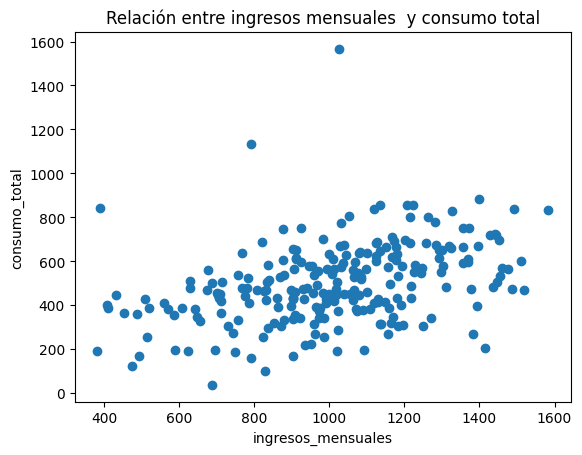

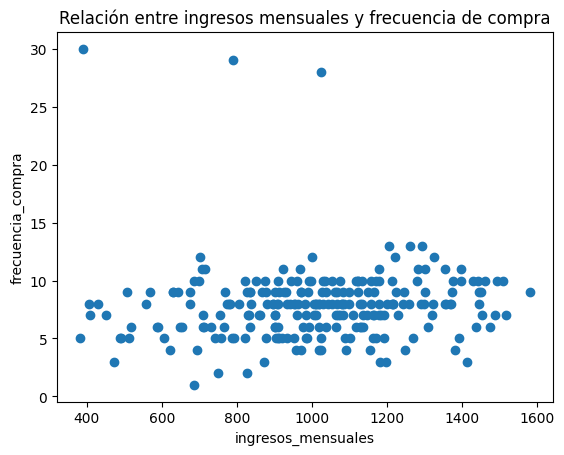

In [16]:
plt.figure()
plt.scatter(df['ingresos_mensuales'], df['consumo_total'])
plt.xlabel('ingresos_mensuales')
plt.ylabel('consumo_total')
plt.title('Relación entre ingresos mensuales  y consumo total')
plt.show()

plt.figure()
plt.scatter(df['ingresos_mensuales'], df['frecuencia_compra'])
plt.xlabel('ingresos_mensuales')
plt.ylabel('frecuencia_compra')
plt.title('Relación entre ingresos mensuales y frecuencia de compra')
plt.show()


**correlaciones positivas mas importantes:**

* frecuencia_compra y consumo_total: 0.764
* tiempo_respuesta y reclamos: 0.624
* ticket_promedio e ingresos_mensuales: 0.575
* ticket_promedio y consumo_total: 0.522


**Correlaciones negativas mas importantes:**

* reclamos y satisfaccion       -0.825
* satisfaccion ytiempo_respuesta   -0.619
* tiempo_respuesta y consumo_total      -0.328


**Relaciones encontradas entre variables:**

- Ingresos mensuales y ticket promedio
- Satisfacción y tiempo de respuesta
- frecuencia de compra y consumo total
- tiempo de respuesta y consumo total


 **Conclusiones:**

 Este analisis de correlación permite a la empresa a identificar que:
 *  el tiempo de respuesta es clave! pues afecta directamente al consumo total y frecuencia de compra y reclamos
 * La satisfacción se ve impactada directamente por el timpo de respuesta
 * el ticket promedio está muy relacionado a los infresos mensuales de los clientes.